# June 29 9 displacement guess in mm

This notebook estimates the bulk speckle displacement in `data/raw/june29_9.mp4`. There is no strict UltraTimTrack result folder or ROI file for this video in the repo, so this is intentionally a **calibrated guess**, not a definitive mechanical measurement.

The pixel-to-mm conversion used here is inferred from other June 29 strict runs in this repo: `mm_per_pixel = 0.066015625`, equivalent to `50.7 mm / 768 px`. That matches the existing pipeline convention.

Important caveat: for a truly defensible conversion we need the actual image depth or direct `mm_per_pixel` for `june29_9.mp4`, and for x/lateral displacement we also need lateral spacing or confirmation that the exported pixels are square.

In [1]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib")

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
if not (ROOT / "ultrasound_tracker").exists():
    ROOT = ROOT.parent.resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from ultrasound_tracker.speckle_confidence import SpeckleConfidenceConfig, _gray_float, _match_patch_at

VIDEO_PATH = ROOT / "data" / "raw" / "june29_9.mp4"
OUT_DIR = ROOT / "results" / "june29_9_displacement_guess"
OUT_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATH = OUT_DIR / "june29_9_global_speckle_displacement_guess.csv"
SUMMARY_PATH = OUT_DIR / "june29_9_displacement_guess_summary.json"
FIG_PATH = OUT_DIR / "june29_9_displacement_guess_timeseries.png"
PREVIEW_PATH = OUT_DIR / "june29_9_displacement_guess_preview.png"

plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 180, "axes.grid": True, "grid.alpha": 0.25})

print(f"Video: {VIDEO_PATH}")
print(f"Outputs: {OUT_DIR}")

Video: /Users/grosbedou/PycharmProjects/NDORMS/data/raw/june29_9.mp4
Outputs: /Users/grosbedou/PycharmProjects/NDORMS/results/june29_9_displacement_guess


## Load the video and find calibration candidates

The notebook first checks whether `june29_9` has a strict metadata file. If not, it looks at other `june29_*` strict outputs and uses their median scale as the guess.

In [2]:
def read_gray_video(path: Path, limit: int | None = None) -> tuple[list[np.ndarray], float, int, tuple[int, int]]:
    cap = cv2.VideoCapture(str(path))
    if not cap.isOpened():
        raise FileNotFoundError(path)
    fps = float(cap.get(cv2.CAP_PROP_FPS))
    n_reported = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    frames: list[np.ndarray] = []
    max_frames = n_reported if limit is None else min(int(limit), n_reported)
    for _ in range(max_frames):
        ok, frame = cap.read()
        if not ok:
            break
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY) if frame.ndim == 3 else frame.copy()
        frames.append(gray)
    cap.release()
    if not frames:
        raise RuntimeError(f"No frames read from {path}")
    return frames, fps if np.isfinite(fps) and fps > 0 else 25.0, n_reported, (height, width)

frames, fps, n_reported, frame_shape = read_gray_video(VIDEO_PATH)
frame_h, frame_w = frame_shape

metadata_rows = []
for path in sorted((ROOT / "results" / "strict_ultratimtrack_runs").glob("june29_*/*_strict_metadata.json")):
    try:
        meta = json.loads(path.read_text())
    except Exception:
        continue
    mm = meta.get("mm_per_pixel")
    video_name = Path(str(meta.get("video", ""))).name
    if mm is None:
        continue
    metadata_rows.append({
        "run": path.parent.name,
        "source_video": video_name,
        "mm_per_pixel": float(mm),
        "inferred_depth_mm_if_full_frame": float(mm) * frame_h,
    })

metadata_df = pd.DataFrame(metadata_rows)
exact = metadata_df[metadata_df["source_video"].eq(VIDEO_PATH.name)] if not metadata_df.empty else pd.DataFrame()
june29_scales = metadata_df[metadata_df["source_video"].str.startswith("june29_", na=False)] if not metadata_df.empty else pd.DataFrame()

if not exact.empty:
    MM_PER_PIXEL_GUESS = float(exact["mm_per_pixel"].median())
    calibration_source = "exact strict metadata for june29_9"
elif not june29_scales.empty:
    MM_PER_PIXEL_GUESS = float(june29_scales["mm_per_pixel"].median())
    calibration_source = "median of other june29 strict runs"
else:
    MM_PER_PIXEL_GUESS = float("nan")
    calibration_source = "not found"

print(f"frames read: {len(frames)} / reported {n_reported}")
print(f"fps: {fps:.3f}")
print(f"frame size: {frame_w} x {frame_h} px")
print(f"mm_per_pixel_guess: {MM_PER_PIXEL_GUESS} ({calibration_source})")
print(f"depth implied by full-frame scale: {MM_PER_PIXEL_GUESS * frame_h if np.isfinite(MM_PER_PIXEL_GUESS) else np.nan:.3f} mm")
display(metadata_df)

frames read: 676 / reported 676
fps: 25.000
frame size: 1024 x 768 px
mm_per_pixel_guess: 0.06601562500000001 (median of other june29 strict runs)
depth implied by full-frame scale: 50.700 mm


,run,source_video,mm_per_pixel,inferred_depth_mm_if_full_frame
0,june29_1,june29_1.mp4,0.066016,50.7
1,june29_1_flat_test,june29_1.mp4,0.066016,50.7
2,june29_1_horizontal_test,june29_1.mp4,0.066016,50.7
3,june29_1_near_horizontal,june29_1.mp4,0.066016,50.7
4,june29_1_near_horizontal_test,june29_1.mp4,0.066016,50.7
5,june29_3,june29_3.mp4,0.066016,50.7


## Detect the active ultrasound rectangle

The video is letterboxed with black margins. The matcher samples points only inside the non-black ultrasound image rectangle, but the main mm conversion below follows the existing strict-run convention: depth divided by the **full encoded frame height**.

A sensitivity scale is also reported for the alternate assumption that the 50.7 mm depth spans only the active rectangle.

active crop: x=277, y=202, w=470, h=365
full-frame mm/px guess: 0.066015625
active-crop sensitivity mm/px: 0.138904110


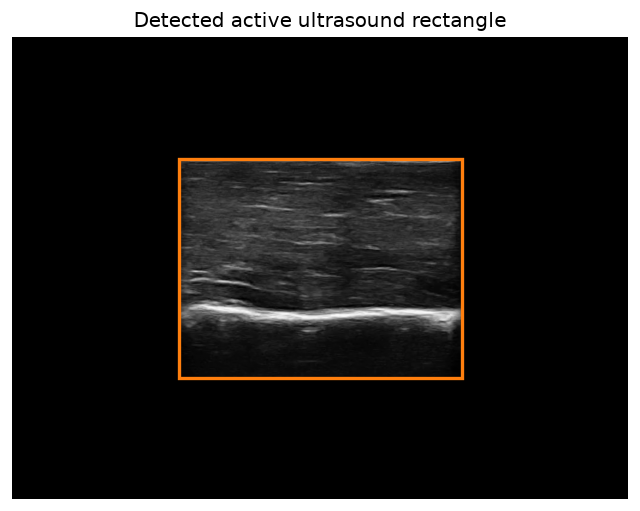

In [3]:
def active_ultrasound_bbox(frame: np.ndarray, threshold: int = 5, min_fraction: float = 0.05) -> tuple[int, int, int, int]:
    mask = np.asarray(frame) > int(threshold)
    active_rows = np.where(mask.mean(axis=1) > float(min_fraction))[0]
    active_cols = np.where(mask.mean(axis=0) > float(min_fraction))[0]
    if len(active_rows) == 0 or len(active_cols) == 0:
        return (0, 0, frame.shape[1], frame.shape[0])
    x0 = int(active_cols[0])
    x1 = int(active_cols[-1])
    y0 = int(active_rows[0])
    y1 = int(active_rows[-1])
    return x0, y0, x1 - x0 + 1, y1 - y0 + 1

crop = active_ultrasound_bbox(frames[0])
x0, y0, crop_w, crop_h = crop
image_depth_guess_mm = MM_PER_PIXEL_GUESS * frame_h if np.isfinite(MM_PER_PIXEL_GUESS) else np.nan
MM_PER_PIXEL_ACTIVE_CROP_SENSITIVITY = image_depth_guess_mm / crop_h if np.isfinite(image_depth_guess_mm) else np.nan

print(f"active crop: x={x0}, y={y0}, w={crop_w}, h={crop_h}")
print(f"full-frame mm/px guess: {MM_PER_PIXEL_GUESS:.9f}")
print(f"active-crop sensitivity mm/px: {MM_PER_PIXEL_ACTIVE_CROP_SENSITIVITY:.9f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.imshow(frames[0], cmap="gray")
rect = plt.Rectangle((x0, y0), crop_w, crop_h, fill=False, edgecolor="tab:orange", linewidth=2)
ax.add_patch(rect)
ax.set_title("Detected active ultrasound rectangle")
ax.set_axis_off()
plt.show()

## Estimate bulk speckle displacement

This is a simple median patch-matching estimate. It samples textured patches inside the active ultrasound crop, matches them frame-to-frame using the same OpenCV ZNCC-style patch matcher used by the speckle confidence code, and takes the median valid frame-to-frame displacement as the bulk image motion.

This estimates image/tissue motion in the video plane. It is not a fascicle-specific strain analysis.

In [4]:
CFG = SpeckleConfidenceConfig(
    block_size=31,
    stride=32,
    search_radius=12,
    min_texture_variance=8.0,
    zncc_low=0.50,
    zncc_high=0.90,
    forward_backward_scale_px=2.5,
)

def sample_texture_points(frame: np.ndarray, crop: tuple[int, int, int, int], cfg: SpeckleConfidenceConfig) -> np.ndarray:
    x0, y0, w, h = crop
    half = int(cfg.block_size) // 2
    margin = half + int(cfg.search_radius) + 4
    xs = np.arange(x0 + margin, x0 + w - margin, int(cfg.stride), dtype=int)
    ys = np.arange(y0 + margin, y0 + h - margin, int(cfg.stride), dtype=int)
    points = []
    for y in ys:
        for x in xs:
            patch = frame[y - half : y + half + 1, x - half : x + half + 1]
            if patch.shape != (cfg.block_size, cfg.block_size):
                continue
            if float(np.var(patch)) >= float(cfg.min_texture_variance):
                points.append([float(x), float(y)])
    points_arr = np.asarray(points, dtype=np.float64)
    if len(points_arr) == 0:
        raise RuntimeError("No valid texture points were found in the active ultrasound crop.")
    return points_arr

def track_bulk_translation(frames: list[np.ndarray], points0: np.ndarray, cfg: SpeckleConfidenceConfig) -> tuple[pd.DataFrame, np.ndarray]:
    positions = np.asarray(points0, dtype=np.float64).copy()
    cumulative = np.zeros(2, dtype=np.float64)
    last_step = np.zeros(2, dtype=np.float64)
    rows = [{
        "frame": 0,
        "time_s": 0.0,
        "step_dx_px": 0.0,
        "step_dy_px": 0.0,
        "cumulative_dx_px": 0.0,
        "cumulative_dy_px": 0.0,
        "valid_points": int(len(points0)),
        "median_zncc": 1.0,
        "median_forward_backward_error_px": 0.0,
    }]
    stored_positions = np.full((len(frames), len(points0), 2), np.nan, dtype=np.float64)
    stored_positions[0] = positions

    for frame_idx in range(len(frames) - 1):
        prev = _gray_float(frames[frame_idx])
        curr = _gray_float(frames[frame_idx + 1])
        displacements = []
        scores = []
        fb_errors = []
        for point in positions:
            forward = _match_patch_at(prev, curr, point, cfg)
            if forward is None:
                continue
            matched, score = forward
            reverse = _match_patch_at(curr, prev, matched, cfg)
            fb_error = float(np.linalg.norm(reverse[0] - point)) if reverse is not None else np.nan
            fb_ok = (not np.isfinite(fb_error)) or fb_error <= float(cfg.forward_backward_scale_px)
            if float(score) >= float(cfg.zncc_low) and fb_ok:
                displacements.append(np.asarray(matched, dtype=np.float64) - point)
                scores.append(float(score))
                fb_errors.append(fb_error)

        if displacements:
            step = np.nanmedian(np.asarray(displacements, dtype=np.float64), axis=0)
            if np.all(np.isfinite(step)):
                last_step = step.copy()
        else:
            step = last_step.copy()

        positions = positions + step
        cumulative = cumulative + step
        stored_positions[frame_idx + 1] = positions
        rows.append({
            "frame": int(frame_idx + 1),
            "time_s": float((frame_idx + 1) / fps),
            "step_dx_px": float(step[0]),
            "step_dy_px": float(step[1]),
            "cumulative_dx_px": float(cumulative[0]),
            "cumulative_dy_px": float(cumulative[1]),
            "valid_points": int(len(displacements)),
            "median_zncc": float(np.nanmedian(scores)) if scores else np.nan,
            "median_forward_backward_error_px": float(np.nanmedian(fb_errors)) if fb_errors else np.nan,
        })
    return pd.DataFrame(rows), stored_positions

points0 = sample_texture_points(frames[0], crop, CFG)
df, tracked_positions = track_bulk_translation(frames, points0, CFG)

for prefix, scale in [("guess", MM_PER_PIXEL_GUESS), ("active_crop_sensitivity", MM_PER_PIXEL_ACTIVE_CROP_SENSITIVITY)]:
    df[f"cumulative_dx_mm_{prefix}"] = df["cumulative_dx_px"] * scale
    df[f"cumulative_dy_mm_{prefix}"] = df["cumulative_dy_px"] * scale
    df[f"displacement_magnitude_mm_{prefix}"] = np.hypot(df["cumulative_dx_px"], df["cumulative_dy_px"]) * scale

df.to_csv(CSV_PATH, index=False)
print(f"sampled texture points: {len(points0)}")
print(f"saved CSV: {CSV_PATH}")
display(df.head())
display(df.tail())

sampled texture points: 127
saved CSV: /Users/grosbedou/PycharmProjects/NDORMS/results/june29_9_displacement_guess/june29_9_global_speckle_displacement_guess.csv


,frame,time_s,step_dx_px,step_dy_px,cumulative_dx_px,cumulative_dy_px,valid_points,median_zncc,median_forward_backward_error_px,cumulative_dx_mm_guess,cumulative_dy_mm_guess,displacement_magnitude_mm_guess,cumulative_dx_mm_active_crop_sensitivity,cumulative_dy_mm_active_crop_sensitivity,displacement_magnitude_mm_active_crop_sensitivity
0,0,0.00,0.0,0.0,0.0,0.0,127,1.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000
1,1,0.04,0.0,0.0,0.0,0.0,127,1.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000
2,2,0.08,2.0,0.0,2.0,0.0,127,0.979194,0.0,0.132031,0.0,0.132031,0.277808,0.0,0.277808
3,3,0.12,0.0,0.0,2.0,0.0,126,0.961204,0.0,0.132031,0.0,0.132031,0.277808,0.0,0.277808
4,4,0.16,1.0,0.0,3.0,0.0,123,0.920287,0.0,0.198047,0.0,0.198047,0.416712,0.0,0.416712


,frame,time_s,step_dx_px,step_dy_px,cumulative_dx_px,cumulative_dy_px,valid_points,median_zncc,median_forward_backward_error_px,cumulative_dx_mm_guess,cumulative_dy_mm_guess,displacement_magnitude_mm_guess,cumulative_dx_mm_active_crop_sensitivity,cumulative_dy_mm_active_crop_sensitivity,displacement_magnitude_mm_active_crop_sensitivity
671,671,26.84,0.0,0.0,63.0,-1.0,119,0.991893,0.0,4.158984,-0.066016,4.159508,8.750959,-0.138904,8.752061
672,672,26.88,0.0,0.0,63.0,-1.0,117,0.990902,0.0,4.158984,-0.066016,4.159508,8.750959,-0.138904,8.752061
673,673,26.92,0.0,0.0,63.0,-1.0,117,0.934555,0.0,4.158984,-0.066016,4.159508,8.750959,-0.138904,8.752061
674,674,26.96,0.0,1.0,63.0,0.0,117,0.960394,0.0,4.158984,0.000000,4.158984,8.750959,0.000000,8.750959
675,675,27.00,0.0,0.0,63.0,0.0,120,1.000000,0.0,4.158984,0.000000,4.158984,8.750959,0.000000,8.750959


In [5]:
summary = {
    "video": str(VIDEO_PATH),
    "n_frames": int(len(frames)),
    "fps": float(fps),
    "frame_shape": [int(frame_h), int(frame_w)],
    "active_crop": [int(v) for v in crop],
    "calibration_source": calibration_source,
    "mm_per_pixel_guess_full_frame": float(MM_PER_PIXEL_GUESS),
    "mm_per_pixel_active_crop_sensitivity": float(MM_PER_PIXEL_ACTIVE_CROP_SENSITIVITY),
    "n_texture_points": int(len(points0)),
    "end_dx_px": float(df["cumulative_dx_px"].iloc[-1]),
    "end_dy_px": float(df["cumulative_dy_px"].iloc[-1]),
    "end_dx_mm_guess": float(df["cumulative_dx_mm_guess"].iloc[-1]),
    "end_dy_mm_guess": float(df["cumulative_dy_mm_guess"].iloc[-1]),
    "max_displacement_mm_guess": float(df["displacement_magnitude_mm_guess"].max()),
    "end_dx_mm_active_crop_sensitivity": float(df["cumulative_dx_mm_active_crop_sensitivity"].iloc[-1]),
    "end_dy_mm_active_crop_sensitivity": float(df["cumulative_dy_mm_active_crop_sensitivity"].iloc[-1]),
    "max_displacement_mm_active_crop_sensitivity": float(df["displacement_magnitude_mm_active_crop_sensitivity"].max()),
    "median_valid_points_per_frame": float(df["valid_points"].median()),
    "median_zncc": float(df["median_zncc"].median()),
}
SUMMARY_PATH.write_text(json.dumps(summary, indent=2), encoding="utf-8")
summary_df = pd.DataFrame([summary]).T.rename(columns={0: "value"})
display(summary_df)
print(f"saved summary: {SUMMARY_PATH}")

,value
video,/Users/grosbedou/PycharmProjects/NDORMS/data/r...
n_frames,676
fps,25.0
frame_shape,"[768, 1024]"
active_crop,"[277, 202, 470, 365]"
calibration_source,median of other june29 strict runs
mm_per_pixel_guess_full_frame,0.066016
mm_per_pixel_active_crop_sensitivity,0.138904
n_texture_points,127
end_dx_px,63.0


saved summary: /Users/grosbedou/PycharmProjects/NDORMS/results/june29_9_displacement_guess/june29_9_displacement_guess_summary.json


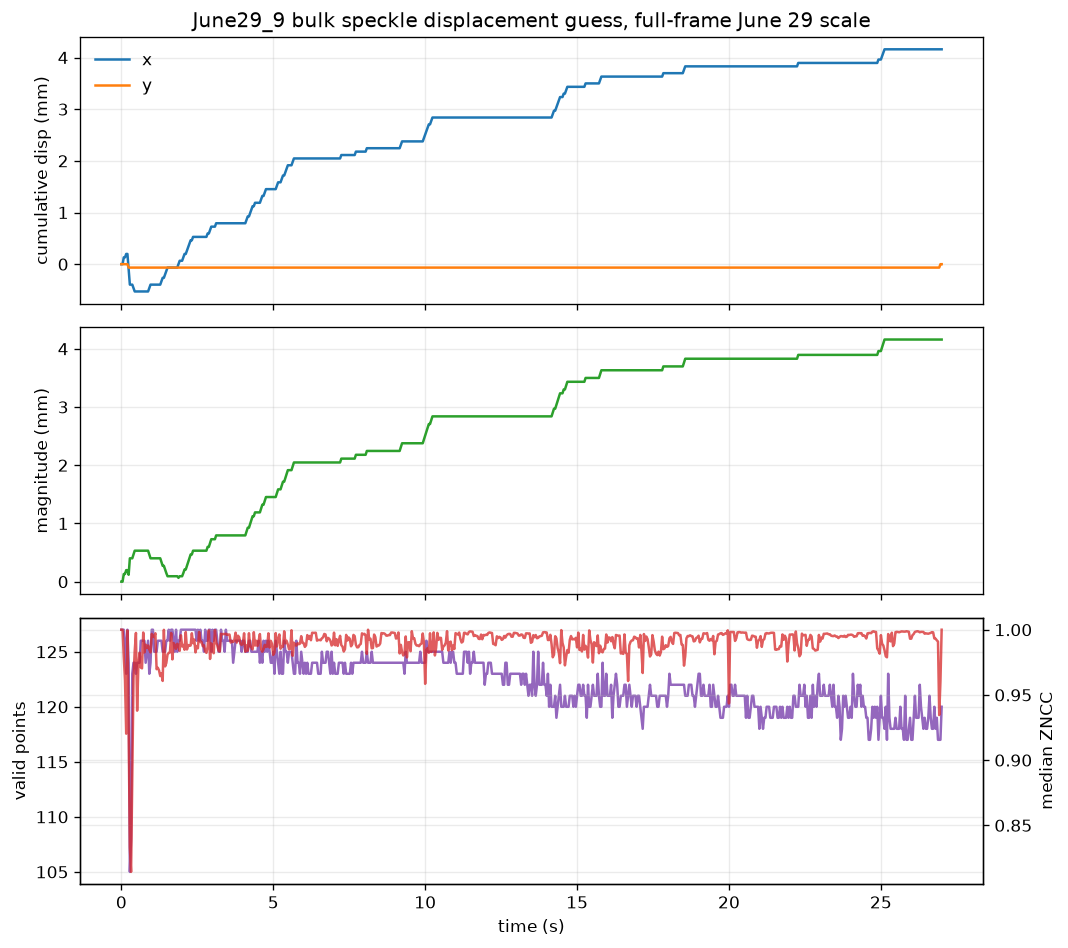

saved figure: /Users/grosbedou/PycharmProjects/NDORMS/results/june29_9_displacement_guess/june29_9_displacement_guess_timeseries.png


In [6]:
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
axes[0].plot(df["time_s"], df["cumulative_dx_mm_guess"], label="x", color="tab:blue")
axes[0].plot(df["time_s"], df["cumulative_dy_mm_guess"], label="y", color="tab:orange")
axes[0].set_ylabel("cumulative disp (mm)")
axes[0].set_title("June29_9 bulk speckle displacement guess, full-frame June 29 scale")
axes[0].legend(frameon=False)

axes[1].plot(df["time_s"], df["displacement_magnitude_mm_guess"], color="tab:green")
axes[1].set_ylabel("magnitude (mm)")

axes[2].plot(df["time_s"], df["valid_points"], label="valid points", color="tab:purple")
ax2 = axes[2].twinx()
ax2.plot(df["time_s"], df["median_zncc"], label="median ZNCC", color="tab:red", alpha=0.75)
axes[2].set_ylabel("valid points")
ax2.set_ylabel("median ZNCC")
axes[2].set_xlabel("time (s)")

fig.tight_layout()
fig.savefig(FIG_PATH, bbox_inches="tight")
plt.show()
print(f"saved figure: {FIG_PATH}")

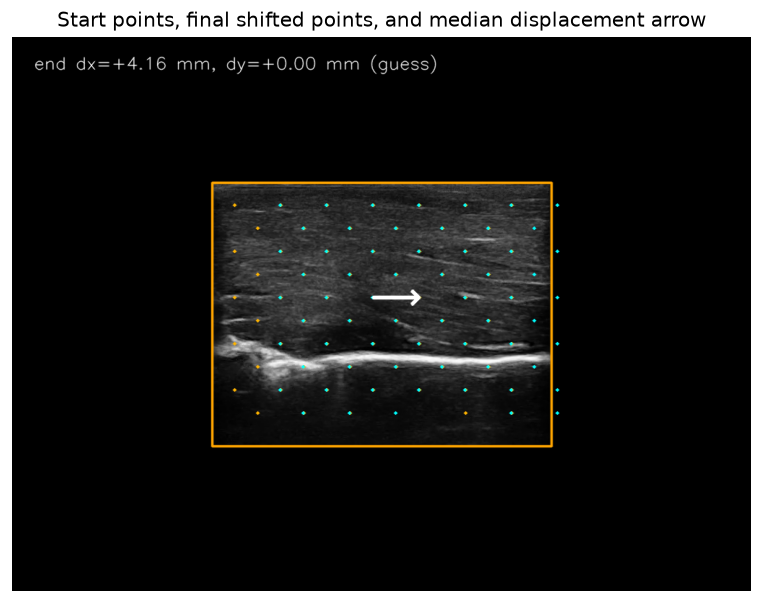

saved preview: /Users/grosbedou/PycharmProjects/NDORMS/results/june29_9_displacement_guess/june29_9_displacement_guess_preview.png


In [7]:
def gray_to_rgb(frame: np.ndarray) -> np.ndarray:
    return cv2.cvtColor(frame, cv2.COLOR_GRAY2RGB)

preview = gray_to_rgb(frames[-1])
start = points0
end = tracked_positions[-1]
for point in start[:: max(1, len(start) // 60)]:
    cv2.circle(preview, tuple(np.rint(point).astype(int)), 2, (255, 180, 0), -1, cv2.LINE_AA)
for point in end[:: max(1, len(end) // 60)]:
    cv2.circle(preview, tuple(np.rint(point).astype(int)), 2, (0, 255, 255), -1, cv2.LINE_AA)

start_center = np.nanmedian(start, axis=0)
end_center = np.nanmedian(end, axis=0)
cv2.arrowedLine(
    preview,
    tuple(np.rint(start_center).astype(int)),
    tuple(np.rint(end_center).astype(int)),
    (255, 255, 255),
    3,
    cv2.LINE_AA,
    tipLength=0.2,
)
cv2.rectangle(preview, (x0, y0), (x0 + crop_w, y0 + crop_h), (255, 165, 0), 2, cv2.LINE_AA)
text = f"end dx={summary['end_dx_mm_guess']:+.2f} mm, dy={summary['end_dy_mm_guess']:+.2f} mm (guess)"
cv2.putText(preview, text, (30, 45), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 0), 4, cv2.LINE_AA)
cv2.putText(preview, text, (30, 45), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 1, cv2.LINE_AA)
cv2.imwrite(str(PREVIEW_PATH), cv2.cvtColor(preview, cv2.COLOR_RGB2BGR))

plt.figure(figsize=(9, 6))
plt.imshow(preview)
plt.axis("off")
plt.title("Start points, final shifted points, and median displacement arrow")
plt.show()
print(f"saved preview: {PREVIEW_PATH}")

## What is missing for a real pixel-to-mm conversion?

For `june29_9.mp4` I do **not** find a matching strict metadata file, ROI file, DICOM header, or explicit scale file in the repo. To transform pixels to mm confidently, we need at least one of:

- the image depth in mm for this exact export, plus confirmation of which pixel height that depth spans;
- a direct `mm_per_pixel` value from the ultrasound/export software;
- a visible calibrated scale bar with reliable pixel endpoints;
- for x displacement, either lateral pixel spacing or confirmation that x and y pixels are square.

This notebook therefore reports the main result using the same full-frame June 29 convention already present in the repo, and also gives an active-crop sensitivity value.

In [8]:
display(Markdown(f"""
### Short conclusion

Using the same-date strict-run calibration (`{MM_PER_PIXEL_GUESS:.9f} mm/px`), the estimated bulk speckle displacement in `june29_9.mp4` is:

- end x displacement: **{summary['end_dx_mm_guess']:+.2f} mm** ({summary['end_dx_px']:+.1f} px)
- end y displacement: **{summary['end_dy_mm_guess']:+.2f} mm** ({summary['end_dy_px']:+.1f} px)
- maximum displacement magnitude: **{summary['max_displacement_mm_guess']:.2f} mm**
- median ZNCC: **{summary['median_zncc']:.3f}** with median **{summary['median_valid_points_per_frame']:.0f}** valid points per frame

If the same 50.7 mm depth actually spans only the detected active ultrasound crop rather than the full encoded frame, the end x displacement would be **{summary['end_dx_mm_active_crop_sensitivity']:+.2f} mm**. That is why the calibration metadata matters here.
"""))


### Short conclusion

Using the same-date strict-run calibration (`0.066015625 mm/px`), the estimated bulk speckle displacement in `june29_9.mp4` is:

- end x displacement: **+4.16 mm** (+63.0 px)
- end y displacement: **+0.00 mm** (+0.0 px)
- maximum displacement magnitude: **4.16 mm**
- median ZNCC: **0.993** with median **123** valid points per frame

If the same 50.7 mm depth actually spans only the detected active ultrasound crop rather than the full encoded frame, the end x displacement would be **+8.75 mm**. That is why the calibration metadata matters here.
